# XAS single run for a photon energy scan 

Goal:
1. Load raw run data.
2. Detect shutter open/closed trains (data/background).
3. Split scan into open-shutter sections (each section = one energy point).
4. Assign nominal photon energy by section index over 270 to 286 eV in 0.5 eV steps.
5. Build background from closed trains and subtract it from open trains.
6. Compute XAS = sum(GMD) / sum(VLS) and plot vs nominal photon energy.
7. save processed data

In [1]:
import glob
import sys
import importlib
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Resolve repo root and import project helpers.
cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "analysis" / "scripts").exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing analysis/scripts")

sys.path.insert(0, str(repo_root / "analysis" / "scripts"))

import config
import data_loading
importlib.reload(data_loading)
load_raw_h5 = data_loading.load_raw_h5

## 1) Configuration

In [2]:
RUN_NO = 58780
MAX_FILES = 20

# VLS preprocessing
ROI = (500, 600)
SIGNAL_BUNCH_RANGE = (0, 60)

# Fixed scan definition: nominal energy is assigned by section index.
SCAN_E_START = 270.0
SCAN_E_STOP = 286.0
SCAN_E_STEP = 0.5

# Fast shutter only (authoritative).
SHUTTER_INDEX_PATH = "/FL2/Beamlines/Fast Shutter/shutter/index"
SHUTTER_VALUE_PATH = "/FL2/Beamlines/Fast Shutter/shutter/value"

# Transition rejection around shutter moves.
TRAIN_RATE_HZ = 10.0  # FLASH2 train rate is typically 10 trains/s.
TRANSITION_TRIM_SECONDS = 3.0

# Section sequence mode: "open" means first section is open, "closed" means first section is closed.
FIRST_SECTION_STATE = "open"

# Protocol prior: require open blocks to be bracketed by closed blocks when possible.
REQUIRE_CLOSED_BRACKETS = False

print(f"RUN_NO={RUN_NO}, ROI={ROI}, SIGNAL_BUNCH_RANGE={SIGNAL_BUNCH_RANGE}")

RUN_NO=58780, ROI=(500, 600), SIGNAL_BUNCH_RANGE=(0, 60)


## 2) Locate files and detect key paths

In [3]:
raw_dir = Path(config.RAW_H5_DIR)
pattern = str(raw_dir / f"*run{RUN_NO}*.h5")

def _file_order_key(p):
    # Sort by numeric index in ..._fileNN_... to avoid lexicographic order (1,10,11,2,...).
    name = Path(p).name
    if "_file" in name:
        tail = name.split("_file", 1)[1]
        num_str = tail.split("_", 1)[0]
        if num_str.isdigit():
            return (0, int(num_str), name)
    return (1, 0, name)

h5_paths = sorted(glob.glob(pattern), key=_file_order_key)
if MAX_FILES is not None:
    h5_paths = h5_paths[:MAX_FILES]
if not h5_paths:
    raise FileNotFoundError(f"No files found for pattern: {pattern}")

print(f"Found {len(h5_paths)} file(s)")
print("First file:", Path(h5_paths[0]).name)

with h5py.File(h5_paths[0], "r") as f:
    if SHUTTER_VALUE_PATH not in f:
        raise KeyError(f"Fast shutter value path not found: {SHUTTER_VALUE_PATH}")
    if SHUTTER_INDEX_PATH not in f:
        raise KeyError(f"Fast shutter index path not found: {SHUTTER_INDEX_PATH}")

print("SHUTTER_VALUE_PATH:", SHUTTER_VALUE_PATH)
print("SHUTTER_INDEX_PATH:", SHUTTER_INDEX_PATH)

Found 13 file(s)
First file: FLASH2_USER1_main_run58780_file1_20260603T100002.1.h5
SHUTTER_VALUE_PATH: /FL2/Beamlines/Fast Shutter/shutter/value
SHUTTER_INDEX_PATH: /FL2/Beamlines/Fast Shutter/shutter/index


## 3) Load run and align Fast Shutter array

In [4]:
def align_by_tid(src_tid, master_tid):
    pos = np.searchsorted(src_tid, master_tid)
    in_range = pos < len(src_tid)
    matched = np.zeros(master_tid.shape, dtype=bool)
    matched[in_range] = src_tid[pos[in_range]] == master_tid[in_range]
    return matched, pos[matched]

def extract_aligned(h5_paths, index_path, value_path, master_tid):
    if (index_path is None) or (value_path is None):
        return None
    out = None
    for fp in h5_paths:
        with h5py.File(fp, "r") as f:
            if (index_path not in f) or (value_path not in f):
                continue
            idx = f[index_path][...]
            val = f[value_path][...]

            # Reduce to one value per train for alignment/assignment.
            if val.ndim == 1:
                val1 = val
            else:
                if val.dtype.kind in ["S", "U", "O"]:
                    # For non-numeric arrays, take first element per train.
                    val1 = np.asarray(val)[:, 0]
                else:
                    val1 = np.nanmean(
                        np.asarray(val, dtype=np.float64),
                        axis=tuple(range(1, val.ndim)),
                    )

            if out is None:
                out_dtype = object if np.asarray(val1).dtype.kind in ["S", "U", "O"] else np.float64
                out = np.full(master_tid.shape, np.nan, dtype=out_dtype)
            matched, src_pos = align_by_tid(idx, master_tid)
            if matched.any():
                out[matched] = val1[src_pos]
    return out

def extract_aligned_gmd(h5_paths, index_path, value_path, master_tid, channel=0):
    if (index_path is None) or (value_path is None):
        return None
    out = None
    for fp in h5_paths:
        with h5py.File(fp, "r") as f:
            if (index_path not in f) or (value_path not in f):
                continue
            idx = f[index_path][...]
            val = f[value_path][...]

            # Keep bunch-resolved GMD; for 3D arrays choose one channel.
            if val.ndim == 3:
                v = np.asarray(val[:, int(channel), :], dtype=np.float64)
            elif val.ndim == 2:
                v = np.asarray(val, dtype=np.float64)
            elif val.ndim == 1:
                v = np.asarray(val, dtype=np.float64)[:, None]
            else:
                continue

            if out is None:
                out = np.full((master_tid.shape[0], v.shape[1]), np.nan, dtype=np.float64)

            matched, src_pos = align_by_tid(idx, master_tid)
            if matched.any():
                out[matched, :v.shape[1]] = v[src_pos]
    return out

data = load_raw_h5(RUN_NO, config=2, max_files=MAX_FILES)
if ROI is not None:
    data = data.crop_vls(*ROI)

master_tid = data.tID.astype(np.float64)
shutter_raw = extract_aligned(h5_paths, SHUTTER_INDEX_PATH, SHUTTER_VALUE_PATH, master_tid)

# Tunnel GMD (bunch-resolved) for optional saving.
GMD_TUNNEL_INDEX_CANDIDATES = [
    "/FL2/Photon Diagnostic/GMD/Pulse resolved energy/energy tunnel/index",
    "/FL2/Photon Diagnostic/GMD/Pulse resolved energy/tunnel/index",
]
GMD_TUNNEL_VALUE_CANDIDATES = [
    "/FL2/Photon Diagnostic/GMD/Pulse resolved energy/energy tunnel/value",
    "/FL2/Photon Diagnostic/GMD/Pulse resolved energy/tunnel/value",
]

gmd_tunnel_index_path = None
gmd_tunnel_value_path = None
with h5py.File(h5_paths[0], "r") as f:
    for p in GMD_TUNNEL_INDEX_CANDIDATES:
        if p in f:
            gmd_tunnel_index_path = p
            break
    for p in GMD_TUNNEL_VALUE_CANDIDATES:
        if p in f:
            gmd_tunnel_value_path = p
            break

gmd_tunnel = extract_aligned_gmd(
    h5_paths, gmd_tunnel_index_path, gmd_tunnel_value_path, master_tid, channel=0
 )

print(f"Loaded VLS shape: {data.vls.shape}")
print(f"Shutter array present: {shutter_raw is not None}")
print(f"Tunnel GMD present: {gmd_tunnel is not None}")

Loading 13 raw H5 file(s) for run 58780 (config 2).
  reading FLASH2_USER1_main_run58780_file1_20260603T100002.1.h5
  reading FLASH2_USER1_main_run58780_file2_20260603T100745.1.h5
  reading FLASH2_USER1_main_run58780_file3_20260603T101520.1.h5
  reading FLASH2_USER1_main_run58780_file4_20260603T102248.1.h5
  reading FLASH2_USER1_main_run58780_file5_20260603T103009.1.h5
  reading FLASH2_USER1_main_run58780_file6_20260603T103739.1.h5
  reading FLASH2_USER1_main_run58780_file7_20260603T104505.1.h5
  reading FLASH2_USER1_main_run58780_file8_20260603T105231.1.h5
  reading FLASH2_USER1_main_run58780_file9_20260603T105959.1.h5
  reading FLASH2_USER1_main_run58780_file10_20260603T110729.1.h5
  reading FLASH2_USER1_main_run58780_file11_20260603T111459.1.h5
  reading FLASH2_USER1_main_run58780_file12_20260603T112226.1.h5
  reading FLASH2_USER1_main_run58780_file13_20260603T112955.1.h5


: 

## 4) Classify trains with Fast Shutter and split into scan sections

This step uses Fast Shutter as the authoritative indicator:

1. Convert shutter values to open/closed masks.
2. Drop trains within `+- TRANSITION_TRIM_SECONDS` around every shutter transition.
3. Find contiguous open blocks and keep all valid measurement sections.
4. If enabled, require each open block to be bracketed by closed shutter (`closed -> open -> closed`).
5. Assign nominal photon energy by section index using the fixed scan grid (270 to 286 eV, 0.5 eV step).

Detected open sections: 14
Transition trim: +- 3.0 s (30 trains)
Open trains kept: 15365
Closed trains kept: 4739
Mean train score (open): 3.15e+05
Mean train score (closed): 2.9e+05


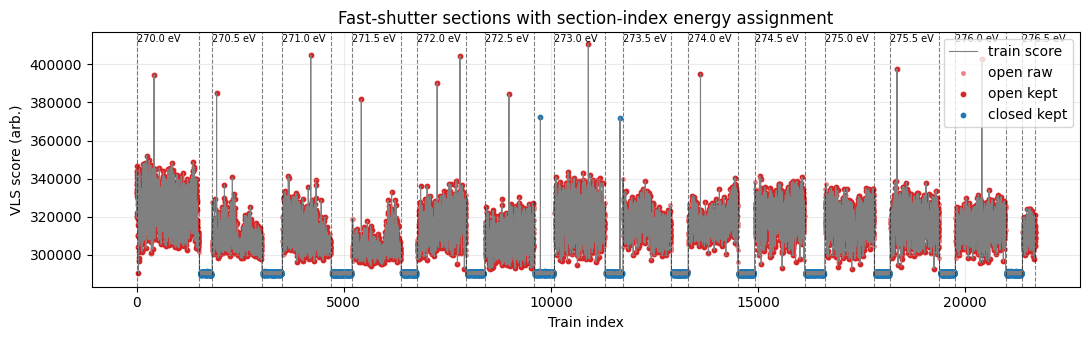

In [ ]:
b0, b1 = SIGNAL_BUNCH_RANGE
train_score = np.nanmean(np.nansum(data.vls[:, b0:b1, :], axis=2), axis=1)

def contiguous_true_blocks(mask):
    m = np.asarray(mask, dtype=bool)
    if m.size == 0:
        return []
    x = m.astype(np.int8)
    starts = np.where(np.diff(np.r_[0, x]) == 1)[0]
    ends = np.where(np.diff(np.r_[x, 0]) == -1)[0] + 1
    return list(zip(starts.tolist(), ends.tolist()))

def classify_shutter(sh):
    if sh is None:
        raise RuntimeError("Shutter parameter not found. Set SHUTTER paths in config.")

    arr = np.asarray(sh)
    finite = np.isfinite(arr.astype(float)) if arr.dtype.kind not in ["S", "U", "O"] else np.array([x is not None for x in arr], dtype=bool)

    # Text labels (open/close).
    if arr.dtype.kind in ["S", "U", "O"]:
        s = np.array([str(x).lower() for x in arr], dtype=object)
        is_open = np.array([("open" in x) or (x in ["1", "on", "true"]) for x in s], dtype=bool)
        is_closed = np.array([("close" in x) or (x in ["0", "off", "false"]) for x in s], dtype=bool)
    else:
        x = arr.astype(float)
        if finite.sum() < 2:
            raise RuntimeError("Not enough finite shutter samples.")
        lo, hi = np.nanpercentile(x[finite], [10, 90])
        thr = 0.5 * (lo + hi)
        is_open = x >= thr
        is_closed = x < thr

    # Safety: flip if the open group has lower VLS score than closed group.
    open_score = np.nanmean(train_score[is_open]) if np.any(is_open) else np.nan
    closed_score = np.nanmean(train_score[is_closed]) if np.any(is_closed) else np.nan
    if np.isfinite(open_score) and np.isfinite(closed_score) and (open_score < closed_score):
        is_open, is_closed = is_closed, is_open

    return is_open, is_closed, finite

is_open_raw, is_closed_raw, finite_sh = classify_shutter(shutter_raw)

# Transition trim: drop trains around every state change.
valid_mask = finite_sh.copy()
transition_idx = np.where(np.diff(is_open_raw.astype(np.int8)) != 0)[0] + 1
trim_n = int(round(TRANSITION_TRIM_SECONDS * TRAIN_RATE_HZ))
for t in transition_idx:
    i0 = max(0, t - trim_n)
    i1 = min(valid_mask.size, t + trim_n + 1)
    valid_mask[i0:i1] = False

# Keep all contiguous open sections (optionally closed-bracketed).
open_blocks = contiguous_true_blocks(is_open_raw & finite_sh)
if REQUIRE_CLOSED_BRACKETS:
    bracketed = []
    for s, e in open_blocks:
        left_closed = (s > 0) and finite_sh[s - 1] and (not is_open_raw[s - 1])
        right_closed = (e < is_open_raw.size) and finite_sh[e] and (not is_open_raw[e])
        if left_closed and right_closed:
            bracketed.append((s, e))
    if bracketed:
        open_blocks = bracketed

if not open_blocks:
    raise RuntimeError("No open shutter sections found for measurement.")

# Fixed scan grid and section->energy mapping by section order.
scan_energies = np.arange(SCAN_E_START, SCAN_E_STOP + 0.5 * SCAN_E_STEP, SCAN_E_STEP, dtype=float)
n_scan = scan_energies.size
n_detected = len(open_blocks)

if n_detected > n_scan:
    print(f"Warning: detected {n_detected} sections; using first {n_scan} to match scan grid.")
    open_blocks = open_blocks[:n_scan]
    n_detected = n_scan
elif n_detected < n_scan:
    print(
        f"Warning: detected only {n_detected} open sections while full scan has {n_scan}. "
        "Proceeding with available sections (likely partial data load, e.g. MAX_FILES=1)."
    )

section_idx = np.full(is_open_raw.shape, -1, dtype=np.int32)
for i, (s, e) in enumerate(open_blocks):
    section_idx[s:e] = i

is_open = (section_idx >= 0) & valid_mask & is_open_raw
is_closed = is_closed_raw & valid_mask

# Section-index nominal assignment for detected sections.
section_nominal = scan_energies[:n_detected]

print(f"Detected open sections: {len(open_blocks)}")
print(f"Transition trim: +- {TRANSITION_TRIM_SECONDS:.1f} s ({trim_n} trains)")
print(f"Open trains kept: {int(np.sum(is_open))}")
print(f"Closed trains kept: {int(np.sum(is_closed))}")
print(f"Mean train score (open): {np.nanmean(train_score[is_open]):.3g}")
print(f"Mean train score (closed): {np.nanmean(train_score[is_closed]):.3g}")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(train_score, lw=0.8, color="0.5", label="train score")
ax.scatter(np.where(is_open_raw)[0], train_score[is_open_raw], s=6, color="lightcoral", label="open raw")
ax.scatter(np.where(is_open)[0], train_score[is_open], s=10, color="tab:red", label="open kept")
ax.scatter(np.where(is_closed)[0], train_score[is_closed], s=10, color="tab:blue", label="closed kept")
for i, (s, e) in enumerate(open_blocks):
    ax.axvline(s, ls="--", lw=0.8, color="k", alpha=0.5)
    ax.axvline(e, ls="--", lw=0.8, color="k", alpha=0.5)
    ax.text(s, np.nanmax(train_score), f"{section_nominal[i]:.1f} eV", fontsize=7, va="bottom")
ax.set_xlabel("Train index")
ax.set_ylabel("VLS score (arb.)")
ax.set_title("Fast-shutter sections with section-index energy assignment")
ax.legend(loc="best")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 4b) Quick section inspection: mean intensity map

Plots mean VLS intensity map for one selected section.

- y-axis: bunch index
- x-axis: VLS pixel

Selection variables are local to the next code cell only.

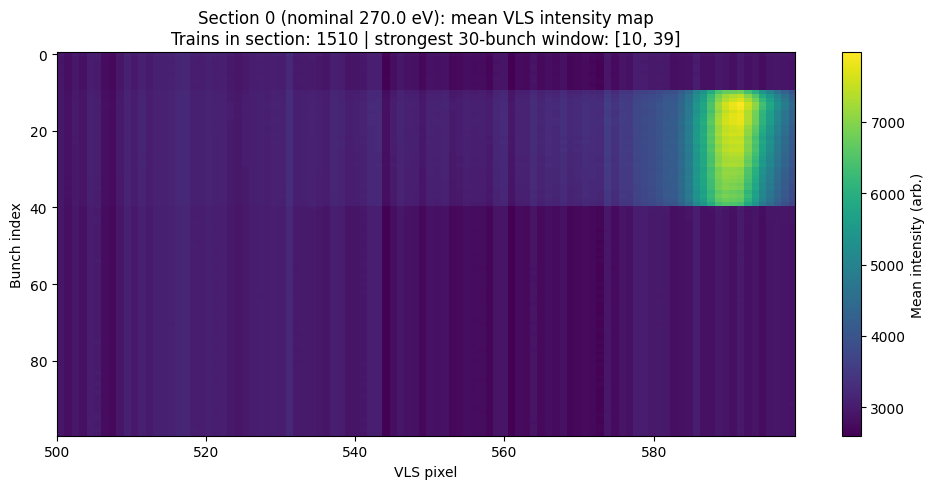

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Local inspection controls (edit here only).
inspect_section_index = 0
inspect_section_energy_ev = None

if len(open_blocks) == 0:
    raise RuntimeError("No detected open sections to inspect.")

# Resolve requested section index.
if inspect_section_energy_ev is not None:
    j = int(np.argmin(np.abs(section_nominal - float(inspect_section_energy_ev))))
    sec_idx = j
else:
    sec_idx = int(inspect_section_index)

if not (0 <= sec_idx < len(open_blocks)):
    raise IndexError(f"Section index {sec_idx} out of range [0, {len(open_blocks)-1}].")

sec_mask = section_idx == sec_idx
if not np.any(sec_mask):
    raise RuntimeError(f"No trains found in section {sec_idx}.")

mean_map = np.nanmean(data.vls[sec_mask, :, :], axis=0)  # (n_bunches, n_pixels_roi)

# Auto-find strongest consecutive 30-bunch signal window in this section.
bunch_profile = np.nanmean(mean_map, axis=1)
window = min(30, bunch_profile.size)
if window > 0:
    rolling = np.convolve(np.nan_to_num(bunch_profile, nan=0.0), np.ones(window, dtype=float), mode="valid")
    best_start = int(np.argmax(rolling))
    best_end = best_start + window - 1
else:
    best_start, best_end = 0, -1

if hasattr(data, "vls_pixel_ax") and (data.vls_pixel_ax is not None):
    pixel_ax = np.asarray(data.vls_pixel_ax, dtype=float)
else:
    pixel_ax = np.arange(mean_map.shape[1], dtype=float)
    if ROI is not None:
        pixel_ax = pixel_ax + ROI[0]

extent = [float(pixel_ax[0]), float(pixel_ax[-1]), mean_map.shape[0] - 0.5, -0.5]

fig, ax = plt.subplots(figsize=(10, 5.0))
im = ax.imshow(mean_map, aspect="auto", cmap="viridis", extent=extent)
fig.colorbar(im, ax=ax, label="Mean intensity (arb.)")
ax.set_xlabel("VLS pixel")
ax.set_ylabel("Bunch index")
ax.set_title(
    f"Section {sec_idx} (nominal {section_nominal[sec_idx]:.1f} eV): mean VLS intensity map"
    f"\nTrains in section: {int(np.sum(sec_mask))} | strongest {window}-bunch window: [{best_start}, {best_end}]"
)
fig.tight_layout()
plt.show()

## 5) Closed-section background subtraction and XAS computation

Background selection rule:

1. If `FIRST_SECTION_STATE == "open"`, the first open section uses the first closed section as background.
2. For all later open sections, use the closed section measured immediately before that open section.
3. If a required closed section is missing, fallback uses all closed trains.

In [ ]:
if not np.any(is_closed):
    raise RuntimeError("No closed trains found: cannot build background.")
if not np.any(is_open):
    raise RuntimeError("No open trains found: cannot compute XAS.")

shot_vls_parts = []
shot_gmd_parts = []
shot_nom_parts = []

# Closed blocks after transition trim.
closed_blocks = contiguous_true_blocks(is_closed)
if not closed_blocks:
    raise RuntimeError("No closed blocks found after transition trimming.")

first_section_state = str(FIRST_SECTION_STATE).strip().lower()
if first_section_state not in ("open", "closed"):
    raise ValueError("FIRST_SECTION_STATE must be 'open' or 'closed'.")

def _prev_closed_indices(open_start):
    prev_block = None
    for cs, ce in closed_blocks:
        if ce <= open_start:
            prev_block = (cs, ce)
        else:
            break
    if prev_block is None:
        return np.array([], dtype=np.int64)
    ps, pe = prev_block
    return np.arange(ps, pe, dtype=np.int64)

# First closed block in the run (used when first section starts open).
first_closed_idx = np.arange(closed_blocks[0][0], closed_blocks[0][1], dtype=np.int64)

for i, (s, e) in enumerate(open_blocks):
    # Open trains belonging to this scan section after transition trimming.
    sec_open_mask = is_open & (section_idx == i)
    sec_open_idx = np.where(sec_open_mask)[0]
    if sec_open_idx.size == 0:
        continue

    # Background policy requested by scan protocol.
    if i == 0 and first_section_state == "open":
        sec_closed_idx = first_closed_idx
    else:
        sec_closed_idx = _prev_closed_indices(s)

    if sec_closed_idx.size == 0:
        # Conservative fallback if required closed block is missing.
        sec_closed_idx = np.where(is_closed)[0]
    if sec_closed_idx.size == 0:
        raise RuntimeError("No closed trains available for background subtraction.")

    bg2d = np.nanmean(data.vls[sec_closed_idx, :, :], axis=0)

    # Subtract from this section's open trains and keep selected bunch range.
    sec_vls = data.vls[sec_open_idx, b0:b1, :] - bg2d[np.newaxis, b0:b1, :]
    sec_vls_sum = np.nansum(sec_vls, axis=2).reshape(-1)
    sec_gmd = data.gmd[sec_open_idx, b0:b1].reshape(-1)
    sec_nom = np.full(sec_gmd.shape, section_nominal[i], dtype=np.float64)

    shot_vls_parts.append(sec_vls_sum)
    shot_gmd_parts.append(sec_gmd)
    shot_nom_parts.append(sec_nom)

if not shot_vls_parts:
    raise RuntimeError("No valid open shots after closed-section background subtraction.")

shot_vls = np.concatenate(shot_vls_parts)
shot_gmd = np.concatenate(shot_gmd_parts)
shot_nom = np.concatenate(shot_nom_parts)

good = np.isfinite(shot_vls) & np.isfinite(shot_gmd) & np.isfinite(shot_nom)
shot_vls = shot_vls[good]
shot_gmd = shot_gmd[good]
shot_nom = shot_nom[good]

xas_total = np.nansum(shot_gmd) / np.nansum(shot_vls)
print(f"Valid open shots: {shot_vls.size}")
print(f"Overall XAS = sum(GMD)/sum(VLS): {xas_total:.6g}")

Valid open shots: 460950
Overall XAS = sum(GMD)/sum(VLS): 0.00013188


## 6) Plot XAS vs nominal photon energy (from section index)

Nominal energy is now defined strictly by scan section order using
`SCAN_E_START`, `SCAN_E_STOP`, and `SCAN_E_STEP`.

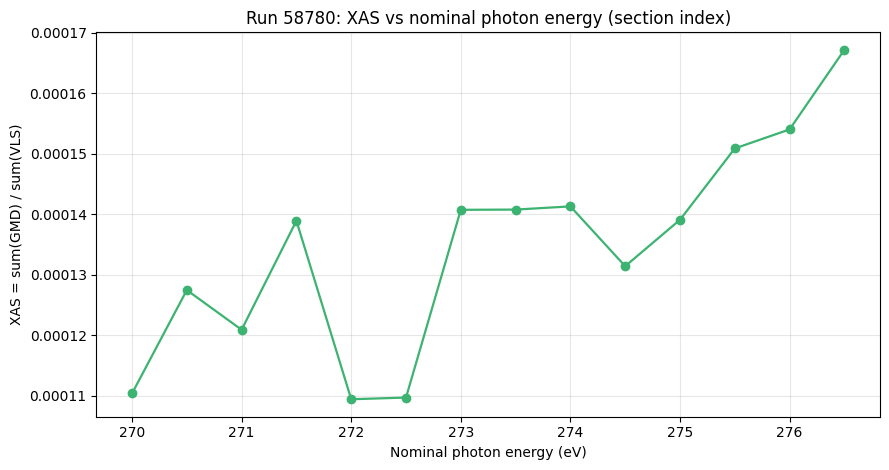

  E_nom (eV)   n shots           XAS
--------------------------------------
    270.0000     44400   0.000110367
    270.5000     34230   0.000127472
    271.0000     33480   0.000120908
    271.5000     33660   0.000138937
    272.0000     33930   0.000109414
    272.5000     33930   0.000109693
    273.0000     34800   0.000140749
    273.5000     33300   0.000140787
    274.0000     34140   0.000141314
    274.5000     34350   0.000131424
    275.0000     34110   0.000139098
    275.5000     33810   0.000150897
    276.0000     34590   0.000154047
    276.5000      8220   0.000167215


In [ ]:
e_grid = np.arange(SCAN_E_START, SCAN_E_STOP + 0.5 * SCAN_E_STEP, SCAN_E_STEP, dtype=float)
e_vals = []
x_vals = []
n_vals = []
for e0 in e_grid:
    m = np.isclose(shot_nom, e0, atol=1e-8)
    if not np.any(m):
        continue
    den = np.nansum(shot_vls[m])
    if np.abs(den) < 1e-12:
        continue
    e_vals.append(float(e0))
    x_vals.append(float(np.nansum(shot_gmd[m]) / den))
    n_vals.append(int(np.sum(m)))

e_vals = np.asarray(e_vals, dtype=float)
x_vals = np.asarray(x_vals, dtype=float)
n_vals = np.asarray(n_vals, dtype=int)
order = np.argsort(e_vals)
e_vals, x_vals, n_vals = e_vals[order], x_vals[order], n_vals[order]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(e_vals, x_vals, "o-", color="mediumseagreen", lw=1.6)
ax.set_xlabel("Nominal photon energy (eV)")
ax.set_ylabel("XAS = sum(GMD) / sum(VLS)")
ax.set_title(f"Run {RUN_NO}: XAS vs nominal photon energy (section index)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"{'E_nom (eV)':>12s}  {'n shots':>8s}  {'XAS':>12s}")
print("-" * 38)
for e, n, x in zip(e_vals, n_vals, x_vals):
    print(f"{e:12.4f}  {n:8d}  {x:12.6g}")

## 7) Select datasets to save

This cell lists available processed datasets and lets you choose exactly which ones to write.

In [ ]:
import numpy as np

# Default save selection (editable).
SAVE_DATA_KEYS = ["vls_cropped", "gmd", "gmd_tunnel", "fast_shutter"]

def _to_save_array(x):
    if x is None:
        return None
    try:
        arr = np.asarray(x)
    except Exception:
        return None
    if arr.dtype.kind == "O":
        return None
    return arr

# Build save map from all currently loaded fields in `data`.
SAVE_DATA_MAP = {}
for k, v in vars(data).items():
    if k.startswith("_"):
        continue
    arr = _to_save_array(v)
    if arr is not None:
        SAVE_DATA_MAP[k] = arr

# Add explicit aliases/extras used in this notebook.
SAVE_DATA_MAP["vls_cropped"] = np.asarray(data.vls, dtype=np.float32)
SAVE_DATA_MAP["gmd_tunnel"] = None if gmd_tunnel is None else np.asarray(gmd_tunnel, dtype=np.float32)
SAVE_DATA_MAP["fast_shutter"] = np.asarray(shutter_raw, dtype=np.float32)
SAVE_DATA_MAP["section_idx"] = np.asarray(section_idx, dtype=np.int32)
SAVE_DATA_MAP["section_nominal"] = np.asarray(section_nominal, dtype=np.float32)
SAVE_DATA_MAP["is_open"] = np.asarray(is_open, dtype=np.uint8)
SAVE_DATA_MAP["is_closed"] = np.asarray(is_closed, dtype=np.uint8)

print("All currently available save keys:")
for k in sorted(SAVE_DATA_MAP.keys()):
    v = SAVE_DATA_MAP[k]
    if v is None:
        print(f"  {k:16s}: unavailable")
    else:
        print(f"  {k:16s}: shape={v.shape}, dtype={v.dtype}")

print()
print("Note: data.gmd is hall GMD from load_raw_h5.")
print("Selected SAVE_DATA_KEYS:", SAVE_DATA_KEYS)

All currently available save keys:
  between_tdc_files: shape=(21690,), dtype=bool
  config          : shape=(), dtype=int64
  fast_shutter    : shape=(21690,), dtype=float32
  gmd             : shape=(21690, 100), dtype=float32
  gmd_tunnel      : shape=(21690, 30), dtype=float32
  is_closed       : shape=(21690,), dtype=uint8
  is_open         : shape=(21690,), dtype=uint8
  mpe             : shape=(21690,), dtype=float32
  section_idx     : shape=(21690,), dtype=int32
  section_nominal : shape=(14,), dtype=float32
  tID             : shape=(21690,), dtype=float64
  vls             : shape=(21690, 100, 100), dtype=float32
  vls_crop_roi    : shape=(2,), dtype=int64
  vls_cropped     : shape=(21690, 100, 100), dtype=float32
  vls_pixel_ax    : shape=(100,), dtype=int64
  z               : shape=(21690, 100), dtype=float32

Note: data.gmd is hall GMD from load_raw_h5.
Selected SAVE_DATA_KEYS: ['vls_cropped', 'gmd', 'gmd_tunnel', 'fast_shutter']


In [ ]:
from datetime import datetime
from pathlib import Path
import h5py
import numpy as np

# Pick processed output directory
if hasattr(config, "COMBINED_DIR"):
    processed_dir = Path(config.COMBINED_DIR).parent
elif hasattr(config, "LOCAL_DAQ_DIR"):
    processed_dir = Path(config.LOCAL_DAQ_DIR).parent
else:
    processed_dir = repo_root / "11022188" / "processed"

processed_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = processed_dir / f"run{RUN_NO}_processed_{timestamp}.h5"

def _to_save_array(x):
    if x is None:
        return None
    try:
        arr = np.asarray(x)
    except Exception:
        return None
    if arr.dtype.kind == "O":
        return None
    return arr

with h5py.File(out_path, "w") as f:
    # Save selected keys; try SAVE_DATA_MAP first, then lazy-resolve from `data`.
    saved_keys = []
    for k in SAVE_DATA_KEYS:
        v = SAVE_DATA_MAP.get(k, None)
        if v is None and hasattr(data, k):
            v = _to_save_array(getattr(data, k))
        if v is None:
            print(f"Skip unavailable key: {k}")
            continue
        f.create_dataset(k, data=v)
        saved_keys.append(k)

    # Minimal metadata
    f.attrs["run_no"] = int(RUN_NO)
    f.attrs["roi_min"] = int(ROI[0])
    f.attrs["roi_max"] = int(ROI[1])
    f.attrs["scan_e_start"] = float(SCAN_E_START)
    f.attrs["scan_e_stop"] = float(SCAN_E_STOP)
    f.attrs["scan_e_step"] = float(SCAN_E_STEP)
    f.attrs["transition_trim_seconds"] = float(TRANSITION_TRIM_SECONDS)
    f.attrs["train_rate_hz"] = float(TRAIN_RATE_HZ)
    f.attrs["first_section_state"] = str(FIRST_SECTION_STATE)
    f.attrs["saved_keys"] = ",".join(saved_keys)

print(f"Saved processed file: {out_path}")

Saved processed file: /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/run58780_processed_20260603_140837.h5


In [19]:
import numpy as np
import re

def _describe_any(v):
    if v is None:
        return "None"
    if np.isscalar(v):
        return f"scalar value={v}"
    if hasattr(v, "shape"):
        try:
            return f"shape={tuple(v.shape)}, dtype={getattr(v, 'dtype', type(v).__name__)}"
        except Exception:
            pass
    try:
        arr = np.asarray(v)
        return f"shape={tuple(arr.shape)}, dtype={arr.dtype}"
    except Exception:
        pass
    try:
        return f"len={len(v)} ({type(v).__name__})"
    except Exception:
        return f"type={type(v).__name__}"

# Exclude IPython history/system variables that flood output but are not analysis state.
def _is_ipy_history_name(name):
    if name in {"In", "Out", "get_ipython", "exit", "quit", "open"}:
        return True
    if re.match(r"^_i\d*$", name):
        return True
    if name in {"_i", "_ii", "_iii", "_ih", "_oh", "_dh", "_"}:
        return True
    if name.startswith("__") and name.endswith("__"):
        return True
    return False

all_names = sorted([k for k in globals().keys() if not _is_ipy_history_name(k)])

print(f"{'variable':30s} {'type':24s} details")
print("-" * 110)
for name in all_names:
    value = globals()[name]
    print(f"{name:30s} {type(value).__name__:24s} {_describe_any(value)}")

print()
print(f"Total variables listed (history-filtered): {len(all_names)}")

variable                       type                     details
--------------------------------------------------------------------------------------------------------------
FIRST_SECTION_STATE            str                      scalar value=open
GMD_TUNNEL_INDEX_CANDIDATES    list                     shape=(2,), dtype=<U68
GMD_TUNNEL_VALUE_CANDIDATES    list                     shape=(2,), dtype=<U68
MAX_FILES                      int                      scalar value=5
Path                           type                     shape=(), dtype=object
REQUIRE_CLOSED_BRACKETS        bool                     scalar value=False
ROI                            tuple                    shape=(2,), dtype=int64
RUN_NO                         int                      scalar value=58780
SAVE_DATA_KEYS                 list                     shape=(4,), dtype=<U12
SAVE_DATA_MAP                  dict                     shape=(), dtype=object
SCAN_E_START                   float                   